Import Modules

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot

Analyze Dataset Sizes / Distribution

In [2]:
#Load in datasets
transactions = pd.read_csv("credit_card_transactions-ibm_v2.csv")
cards = pd.read_csv("sd254_cards.csv")
users = pd.read_csv("sd254_users.csv")

In [3]:
print(transactions.isna().sum())
print(transactions.describe())


User                     0
Card                     0
Year                     0
Month                    0
Day                      0
Time                     0
Amount                   0
Use Chip                 0
Merchant Name            0
Merchant City            0
Merchant State     2720821
Zip                2878135
MCC                      0
Errors?           23998469
Is Fraud?                0
dtype: int64
               User          Card          Year         Month           Day  \
count  2.438690e+07  2.438690e+07  2.438690e+07  2.438690e+07  2.438690e+07   
mean   1.001019e+03  1.351366e+00  2.011955e+03  6.525064e+00  1.571812e+01   
std    5.694612e+02  1.407154e+00  5.105921e+00  3.472355e+00  8.794073e+00   
min    0.000000e+00  0.000000e+00  1.991000e+03  1.000000e+00  1.000000e+00   
25%    5.100000e+02  0.000000e+00  2.008000e+03  3.000000e+00  8.000000e+00   
50%    1.006000e+03  1.000000e+00  2.013000e+03  7.000000e+00  1.600000e+01   
75%    1.477000e+03  2.000000

In [4]:
print(cards.describe())
print(cards.isna().sum())

              User   CARD INDEX   Card Number          CVV  Cards Issued  \
count  6146.000000  6146.000000  6.146000e+03  6146.000000   6146.000000   
mean   1003.477058     1.472502  4.820426e+15   506.220794      1.503091   
std     571.724745     1.463294  1.328582e+15   289.431123      0.519191   
min       0.000000     0.000000  3.001055e+14     0.000000      1.000000   
25%     508.250000     0.000000  4.486365e+15   257.000000      1.000000   
50%    1004.000000     1.000000  5.108957e+15   516.500000      1.000000   
75%    1493.750000     2.000000  5.585237e+15   756.000000      2.000000   
max    1999.000000     8.000000  6.997197e+15   999.000000      3.000000   

       Year PIN last Changed  
count            6146.000000  
mean             2013.436707  
std                 4.270699  
min              2002.000000  
25%              2010.000000  
50%              2013.000000  
75%              2017.000000  
max              2020.000000  
User                     0
CARD INDE

In [5]:
print("\nDescription of User Dataset:")
print(users.describe())

print("\nNull Values for Users:")
print(users.isna().sum())


Description of User Dataset:
       Current Age  Retirement Age   Birth Year  Birth Month    Apartment  \
count  2000.000000     2000.000000  2000.000000  2000.000000   528.000000   
mean     45.391500       66.237500  1973.803000     6.439000   693.547348   
std      18.414092        3.628867    18.421234     3.565338  1897.157861   
min      18.000000       50.000000  1918.000000     1.000000     1.000000   
25%      30.000000       65.000000  1961.000000     3.000000     5.000000   
50%      44.000000       66.000000  1975.000000     7.000000    10.000000   
75%      58.000000       68.000000  1989.000000    10.000000    95.250000   
max     101.000000       79.000000  2002.000000    12.000000  9940.000000   

            Zipcode     Latitude    Longitude   FICO Score  Num Credit Cards  
count   2000.000000  2000.000000  2000.000000  2000.000000       2000.000000  
mean   50535.412000    37.389225   -91.554765   709.734500          3.073000  
std    29359.754742     5.114324    16.

In [6]:
print("Description of Chip Usage Data:")
print(transactions['Use Chip'].describe())

print("\nList of Unique Chip Usage Values:")
print(transactions['Use Chip'].unique())

print("\nDescription of Fraud Purchases Chip Usage:")
print(transactions[transactions['Is Fraud?'] == 1]['Use Chip'].describe())

Description of Chip Usage Data:
count              24386900
unique                    3
top       Swipe Transaction
freq               15386082
Name: Use Chip, dtype: object

List of Unique Chip Usage Values:
['Swipe Transaction' 'Online Transaction' 'Chip Transaction']

Description of Fraud Purchases Chip Usage:
count       0
unique      0
top       NaN
freq      NaN
Name: Use Chip, dtype: object


Data Transformation

In [7]:
#Avoids warning about deprecated feature
pd.set_option('future.no_silent_downcasting', True)

#Transactions are given as strings -> transformed to float
transactions['Amount'] = pd.to_numeric(transactions['Amount'].replace("\\$", "", regex=True).astype(float), errors='coerce')

#Turned fraud status into a binary classification
transactions['Is Fraud?'] = transactions['Is Fraud?'].replace({'Yes':1, 'No':0})

Graphs

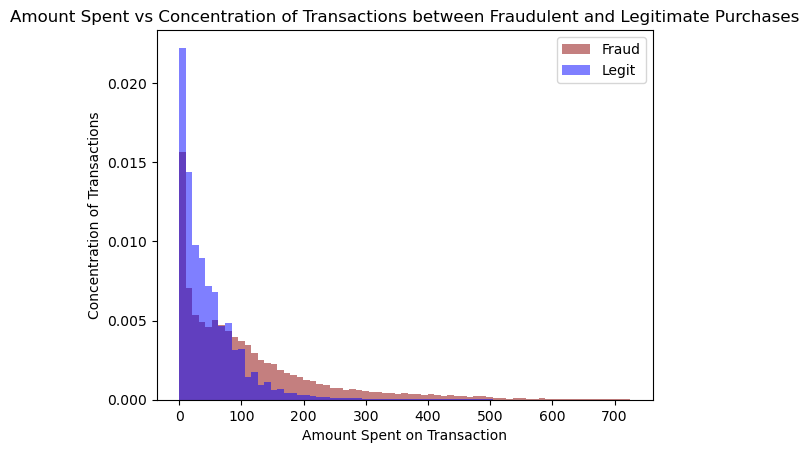

In [8]:
%matplotlib inline

bins = np.linspace(0, 725, 70)

#Group purchases to fraud status
pyplot.hist(transactions[transactions['Is Fraud?'] == 1]['Amount'], bins=bins, alpha = 0.5, density=True, label='Fraud', color='darkred')
pyplot.hist(transactions[transactions['Is Fraud?'] == 0]['Amount'], bins=bins, alpha = 0.5, density=True, label='Legit', color='blue')

pyplot.xlabel("Amount Spent on Transaction")
pyplot.ylabel("Concentration of Transactions")

pyplot.title("Amount Spent vs Concentration of Transactions between Fraudulent and Legitimate Purchases")

pyplot.legend(loc='upper right')

pyplot.show()

#Seemingly perfect for a Box-Cox transformation to normalize data

In [9]:
#Count of Fraud within each type of Transaction
onlineFraud = transactions.loc[(transactions['Use Chip'] == 'Online Transaction') & (transactions['Is Fraud?'] == 1)].size
swipeFraud = transactions.loc[(transactions['Use Chip'] == 'Swipe Transaction') & (transactions['Is Fraud?'] == 1)].size
chipFraud = transactions.loc[(transactions['Use Chip'] == 'Chip Transaction') & (transactions['Is Fraud?'] == 1)].size

#Count of total transactions within each type
onlineTotal = transactions[transactions['Use Chip'] == 'Online Transaction'].size
swipeTotal = transactions[transactions['Use Chip'] == 'Swipe Transaction'].size
chipTotal = transactions[transactions['Use Chip'] == 'Chip Transaction'].size

#Count of legit transactions within each type
onlineLegit = onlineTotal - onlineFraud
swipeLegit = swipeTotal - swipeFraud
chipLegit = chipTotal - chipFraud

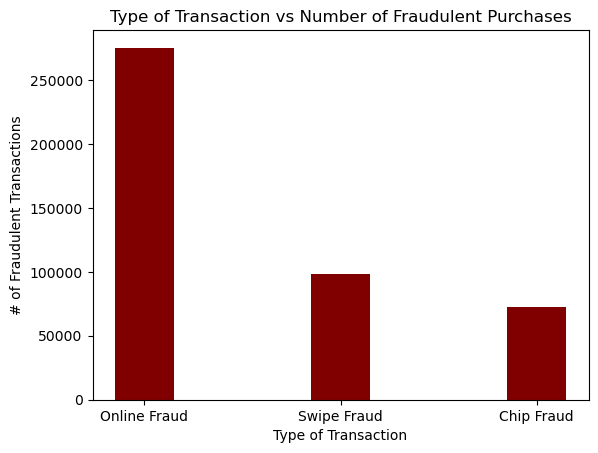

In [10]:
pyplot.bar(x=['Online Fraud', 'Swipe Fraud', 'Chip Fraud'], height= [onlineFraud, swipeFraud, chipFraud], color = 'maroon', width = 0.3)

pyplot.xlabel("Type of Transaction")
pyplot.ylabel("# of Fraudulent Transactions")
pyplot.title("Type of Transaction vs Number of Fraudulent Purchases")

pyplot.show()

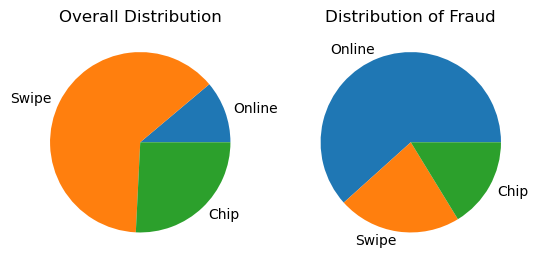

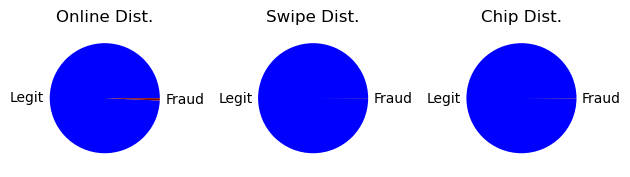

In [11]:
colorScheme = ["blue", "maroon"]

#Distributions of all transactions AND distribution of fraud across all fraud transactions

pyplot.subplot(1,2,1)
pyplot.pie(x = [onlineTotal, swipeTotal, chipTotal], labels=["Online", "Swipe", "Chip"])
pyplot.title("Overall Distribution")

pyplot.subplot(1,2,2)
pyplot.pie(x=[onlineFraud, swipeFraud, chipFraud], labels=["Online", "Swipe", "Chip"])
pyplot.title("Distribution of Fraud")

pyplot.show()

#Pie graphs of distribution of fraud purchases vs legit purchases

pyplot.subplot(1,3,1)
pyplot.pie(x=[onlineLegit, onlineFraud], labels=["Legit", "Fraud"], colors=colorScheme)
pyplot.title("Online Dist.")

pyplot.subplot(1,3,2)
pyplot.pie(x=[swipeLegit, swipeFraud], labels=["Legit", "Fraud"], colors=colorScheme)
pyplot.title("Swipe Dist.")

pyplot.subplot(1,3,3)
pyplot.pie(x=[chipLegit, chipFraud], labels=["Legit", "Fraud"], colors=colorScheme)
pyplot.title("Chip Dist.")

pyplot.tight_layout()
pyplot.show()

In [12]:
#Fraud transactions per month:
months = transactions['Month'].unique()
monthsFraud = []

for month in months:
    monthsFraud.append(transactions.loc[(transactions['Month'] == month) & (transactions['Is Fraud?'] == 1)].size)

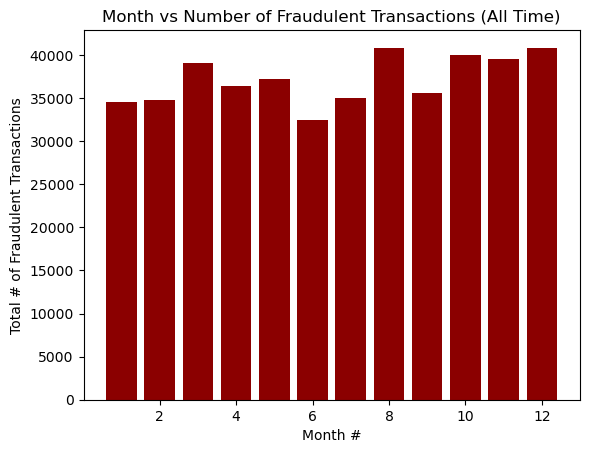

In [13]:
pyplot.bar(x=months, height = monthsFraud, color='darkred', width=0.8)

pyplot.xlabel("Month #")
pyplot.ylabel("Total # of Fraudulent Transactions")
pyplot.title("Month vs Number of Fraudulent Transactions (All Time)")

pyplot.show()